LABORATORIO 1 


In [1]:
# Importando librerias
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [2]:
# Obteniendo los datos 
data = pd.read_csv('bmw.csv', delimiter=',')

# Cuantificando los datos
data['transmission'] = data['transmission'].map({'Automatic':1, 'Manual':2, 'Semi-Auto':3 })
data['fuelType'] = data['fuelType'].map({'Diesel':1, 'Petrol':2, 'Other':3, 'Hybrid':4})

# Eliminando filas con valores nulos
data = data.dropna()

# Asignando las columnas a X y Y
x = data[['year','transmission','mileage','fuelType','tax','mpg','engineSize']]
y = data['price']

In [3]:
print(x)

       year  transmission  mileage  fuelType  tax   mpg  engineSize
0      2014             1    67068       1.0  125  57.6         2.0
1      2018             1    14827       2.0  145  42.8         2.0
2      2016             1    62794       1.0  160  51.4         3.0
3      2017             1    26676       1.0  145  72.4         1.5
4      2014             1    39554       1.0  160  50.4         3.0
...     ...           ...      ...       ...  ...   ...         ...
10776  2016             1    40818       1.0  150  54.3         2.0
10777  2016             1    42947       1.0  125  60.1         2.0
10778  2017             2    25468       2.0  200  42.8         2.0
10779  2014             1    45000       1.0   30  64.2         2.0
10780  2017             1    59432       1.0  125  57.6         2.0

[10778 rows x 7 columns]


In [4]:
#Verificando que no queden filas con valores nulos
print(data.isnull().sum())


model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64


In [5]:
print(y)

0        11200
1        27000
2        16000
3        12750
4        14500
         ...  
10776    19000
10777    14600
10778    13100
10779     9930
10780    15981
Name: price, Length: 10778, dtype: int64


DECLARANDO LA FUNCION DE NORMALIZACION

In [6]:
def normalizacion(x):

    x_norm = x.copy()
    miu = np.zeros(x.shape[1])
    sigma = np.zeros(x.shape[1])

    miu = np.mean(x , axis=0)
    sigma = np.std(x , axis=0)
    x_norm = (x - miu)/sigma
    
    return x_norm, miu, sigma

In [7]:
# obteniendo la media y desviacion estandar
x_norm, miu, sigma = normalizacion(x)
print('Las medias obtenidas son: ',miu)
print(' ')
print("Las desviaciones estandars son: ",sigma)

Las medias obtenidas son:  year             2017.079235
transmission        2.100297
mileage         25498.537391
fuelType            1.406662
tax               131.726202
mpg                56.283689
engineSize          2.168278
dtype: float64
 
Las desviaciones estandars son:  year                2.349148
transmission        0.869184
mileage         25145.003114
fuelType            0.643321
tax                61.490282
mpg                30.567535
engineSize          0.551200
dtype: float64


Concatenar la columna de Unos a x

In [8]:
m = y.size
x = np.concatenate([np.ones((m, 1)), x_norm], axis=1)
# imprimiendo la primera fila de x
print(x[:1])

[[ 1.         -1.31078843 -1.26589588  1.6531898  -0.63212892 -0.10938641
   0.04306239 -0.30529401]]


FUNCION DE COSTO

In [9]:
def costo(x , y , theta):

    J = []
    m = y.size

    J = (1 / (2 * m)) * np.sum(np.square(np.dot(x, theta) - y))
    
    return J


DESCENSO POR EL GRADIENTE

In [10]:
def gradiente(x, y, theta, alpha, num_iters):

    theta = theta.copy()
    J_history = []
    m = y.size

    for i in range(num_iters):
        theta = theta - (alpha / m ) * (np.dot(x, theta) - y).dot(x)
        J_history.append(costo(x, y, theta))

    return theta, J_history


In [11]:
# ejecutando el descenso por el gradiente
alpha = 0.01
num_iters = 10000
theta1 = np.zeros(8)

theta, J_history = gradiente(x, y, theta1, alpha, num_iters)

print("Valores de theta encontrados: ",theta)

Valores de theta encontrados:  [ 2.27345967e+04  4.81169096e+03  1.23298216e+02 -3.03915651e+03
  8.09752533e+02 -1.90011155e+01  3.83507630e+02  5.63992881e+03]


GRAFICANDO LA FUNCION DE COSTO

Text(0, 0.5, 'Costo de J')

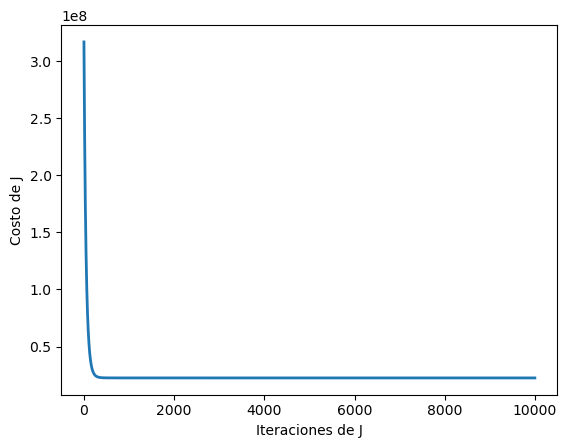

In [12]:
plt.plot(np.arange(len(J_history)), J_history, lw=2)
plt.xlabel("Iteraciones de J")
plt.ylabel("Costo de J")

REALIZANDO PREDICCIONES

In [13]:
pred1 = np.array([ 2019, 1, 400, 1, 100, 50, 5])

# normalizando los datos de entrada
x1 = (pred1 - miu) / sigma
pred1 = np.append(1 , x1)

y_inferida1 = np.dot(pred1, theta)
print("El precio del autos es: ",y_inferida1)

El precio del autos es:  57939.85284793371


ECUACION DE LA NORMAL


In [14]:
def ecNormal(x,y):
    theta = np.zeros(x.shape[1])

    theta = np.dot(np.dot(np.linalg.inv(np.dot(x.T, x)),x.T),y) 

    return theta

In [15]:
theta = ecNormal(x, y)
print("valores de theta:", theta)

valores de theta: [ 2.27345967e+04  4.81169096e+03  1.23298216e+02 -3.03915651e+03
  8.09752533e+02 -1.90011154e+01  3.83507630e+02  5.63992881e+03]


In [ ]:
x1 = np.array([1, 2019, 1, 400, 1, 100, 50, 5])
resultado = np.dot(theta,x1)

print("El resultado es:",resultado)

El resultado es: 8568283.996253338
